# Study 771 — Box-Office-Bomb — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed short leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `f3ff7b3017ec`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from box_office_bomb import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching DIS + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} flops resolved")


panel loaded; 16 of 16 flops resolved


## 1. One-sample *t* across independent flop events

Each flop is one independent event, so the unit is a one-sample *t* of the per-event abnormal return — **not** a daily panel (which would fake precision).

In [2]:
for label, col in [('2wk post','post_s'),('1mo post','post_l'),('2wk pre','pre_s'),('1mo pre','pre_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<9s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk post  n=16  mean=-1.034%  sd=2.70%  t=-1.533
1mo post  n=16  mean=-1.767%  sd=4.36%  t=-1.622
2wk pre   n=16  mean=+0.001%  sd=3.20%  t=+0.001
1mo pre   n=16  mean=-1.109%  sd=5.49%  t=-0.809


## 2. Random-window placebo — is the post-flop sag inside the luck cloud?

For each event we redraw a random, non-flop 2-week window on DIS vs SPY and recompute the abnormal return; 20 seeds × 200 draws. If the observed mean sits in the *left tail* of that null, it isn't ordinary tracking noise. (Note the placebo mean is itself slightly negative — DIS lagged SPY over 2010–2026.)

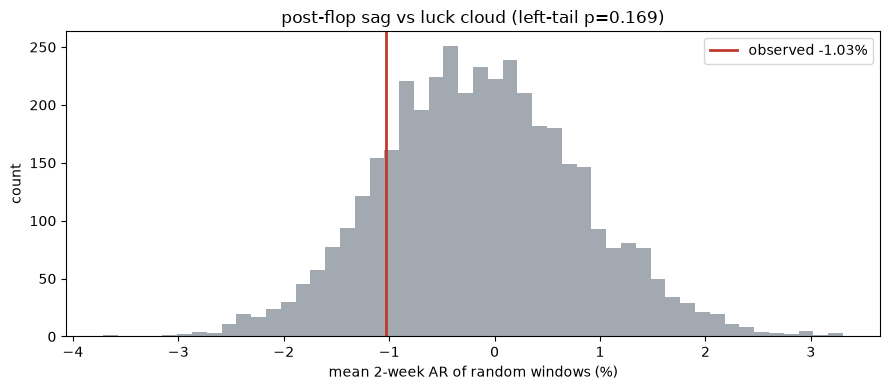

placebo: {'obs': -0.0103, 'placebo_mean': -0.0012, 'placebo_sd': 0.0095, 'p_value': 0.169, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'post_s', k=10, tail='left')
import numpy as np
dis, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = dis.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-11))
        vals.append(float(dis.loc[common[p+10]]/dis.loc[common[p]] - spy.loc[common[p+10]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#c0392b', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 2-week AR of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"post-flop sag vs luck cloud (left-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the sag one bad film, or broad?

In [4]:
x = inc['post_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = -1.533
jackknife t range [-1.801, -1.088] over 16 leave-one-out draws


## 4. Tradability — the SHORT, net of costs

Calendar-known entry, so the signal window and the tradable window are the same. You *short* DIS, so a negative post-window is a positive short P&L — but with *t* ≈ 1.4–1.5 it's not distinguishable from zero, and shorting a mega-cap 16 times in 13 years is capacity- and borrow-trivial.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, short_col, label in [('post_s','short_s_net','2wk post'),('post_l','short_l_net','1mo post')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[short_col].values); n10 = st.one_sample_t(inc10[short_col].values)
    print(f'{label:<9s} gross DIS-SPY {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  SHORT net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  SHORT net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

2wk post  gross DIS-SPY -1.034% (t=-1.53)  SHORT net@5 +0.934% (t=+1.38)  SHORT net@10 +0.834% (t=+1.24)
1mo post  gross DIS-SPY -1.767% (t=-1.62)  SHORT net@5 +1.667% (t=+1.53)  SHORT net@10 +1.567% (t=+1.44)


## 5. Synthetic positive control — the detector works, and the null is quiet

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted post-flop sell-off monotonically. At n = 16 with a 10-day AR the machinery needs a *large* real drop to reach significance — which frames why the observed −1% shows up only as a whiff.

null: mean t=+0.07 sd=1.03  |t|>=2 in 0/20 seeds
planted -1%: mean AR -0.119%  t=-0.14
planted -2%: mean AR -1.119%  t=-1.35


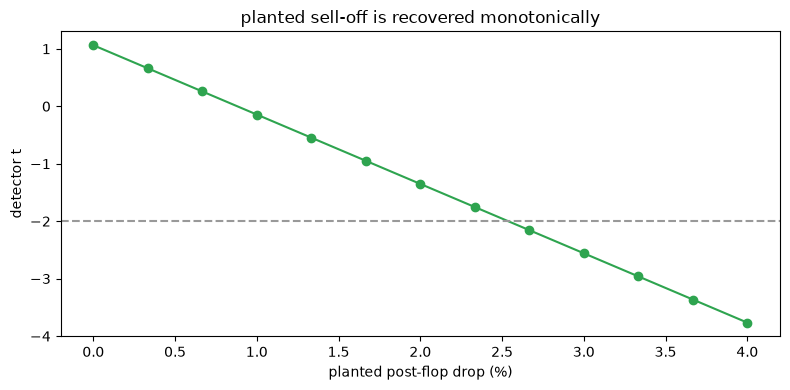

In [6]:
null_ts = np.array([st.synthetic_detect(drop=0.0, seed=773+s, k=10)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for d in (0.01, 0.02):
    r = st.synthetic_detect(drop=d, seed=773, k=10)
    print(f'planted -{d*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
drops = np.linspace(0, 0.04, 13)
ts = [st.synthetic_detect(drop=d, seed=773, k=10)['t'] for d in drops]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(drops*100, ts, 'o-', color='#2ea44f')
ax.axhline(-2, color='0.6', ls='--'); ax.set_xlabel('planted post-flop drop (%)'); ax.set_ylabel('detector t')
ax.set_title('planted sell-off is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The sign is the folklore's — DIS under-performs SPY after a flop at both horizons (−1.03% / −1.77%) and the jackknife keeps *t* negative on every leave-one-out — but |*t*| ≈ 1.5–1.6 is short of significance, the placebo p is 0.14–0.17, the up-rate is a coin-flip, and part of the raw sag is just Disney's decade-long drag vs SPY. **Tradability: Mirage.** The short earns ~+0.9–1.7% per event with *t* ≈ 1.4–1.5 (insignificant), fires 16 times in 13 years, and sits inside a multi-window search.